# 02 - Exploratory Data Analysis (Raw Data)

This notebook explores the cleaned dataset as-is, before any feature engineering:

- Distribution of numerical columns
- Outlier inspection through boxplots
- Distribution of the categorical columns (`Education`, `Marital_Status`)

The goal is to understand the raw data before deriving new features from it.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv("../data/processed/01_cleaned.csv")
df.shape

(2216, 26)

## Numerical Features

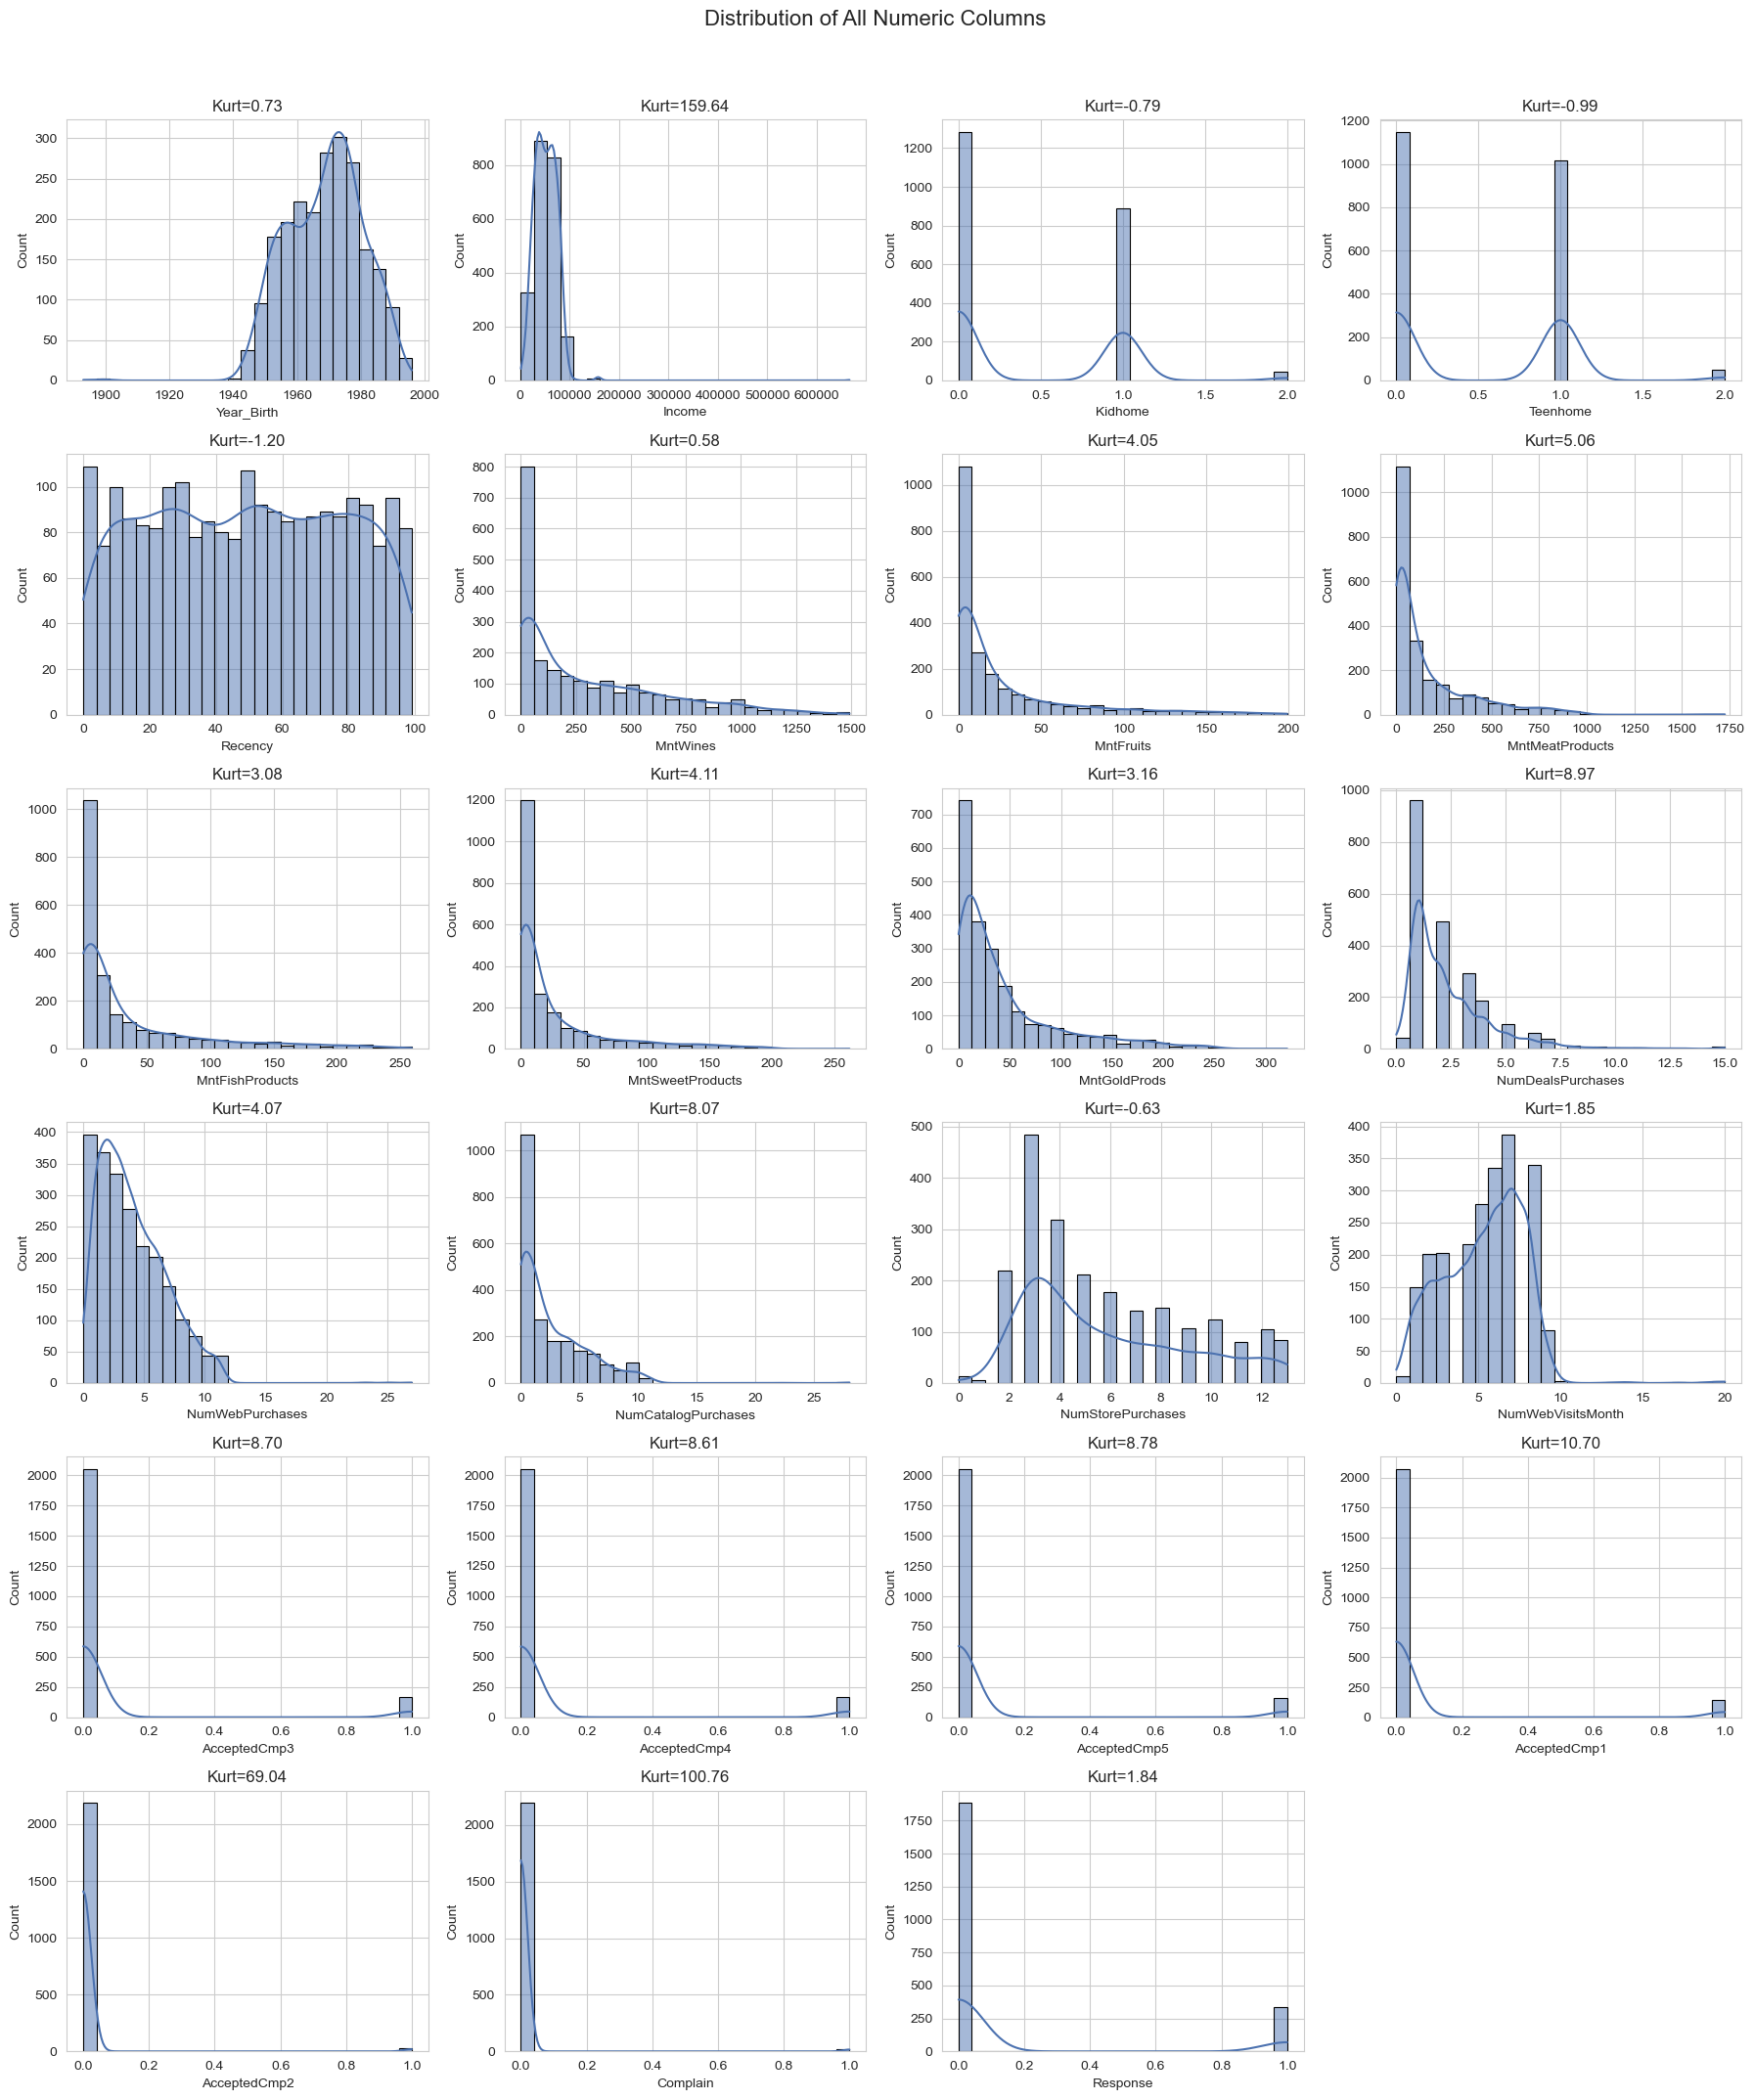

In [3]:
num_cols = df.select_dtypes(include="number").columns.tolist()

n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col],
        kde=True,
        bins=25,
        color="#4C72B0",
        edgecolor="black",
        ax=axes[i],
    )
    kurt_value = df[col].kurtosis()
    axes[i].set_title(f"Kurt={kurt_value:.2f}", fontsize=12)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of All Numeric Columns", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

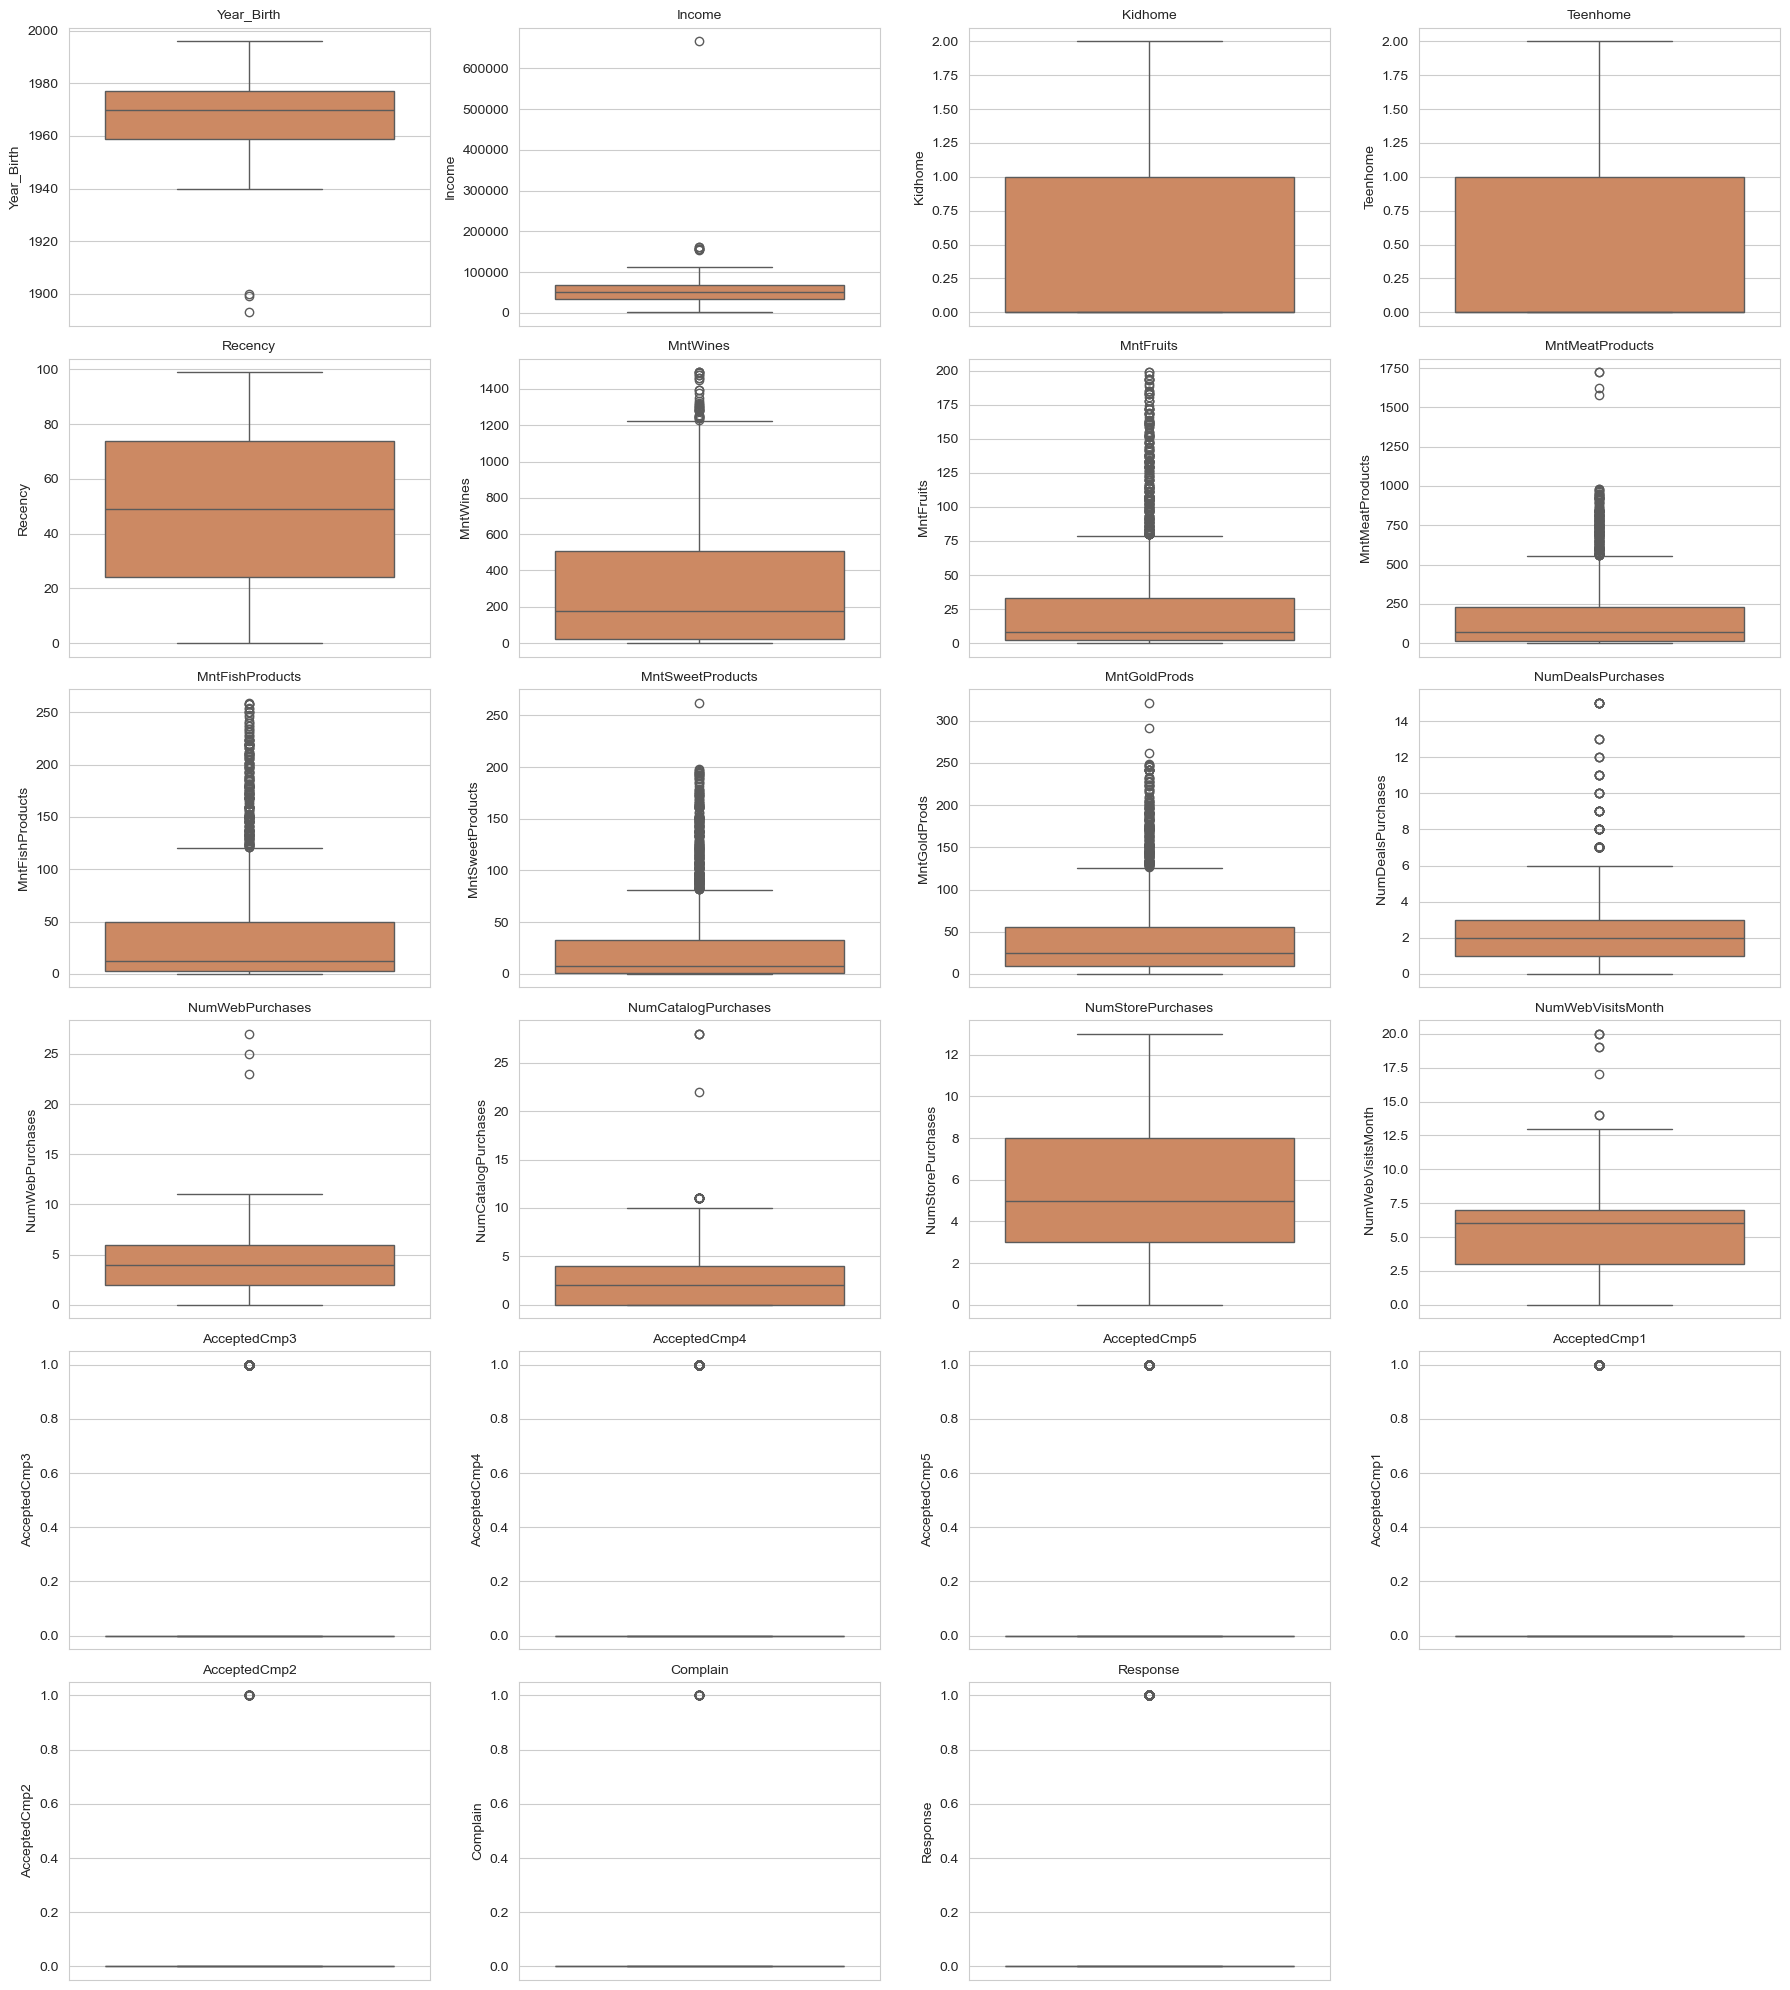

In [4]:
fig, axes = plt.subplots(6, 4, figsize=(18, 20))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#DD8452")
    axes[i].set_title(col, fontsize=10)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

## Categorical Features

C:\Users\Windows\AppData\Local\Temp\ipykernel_21276\915530496.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Education"], order=df["Education"].value_counts().index, ax=axes[0], palette="Blues_r")
C:\Users\Windows\AppData\Local\Temp\ipykernel_21276\915530496.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Marital_Status"], order=df["Marital_Status"].value_counts().index, ax=axes[1], palette="Greens_r")


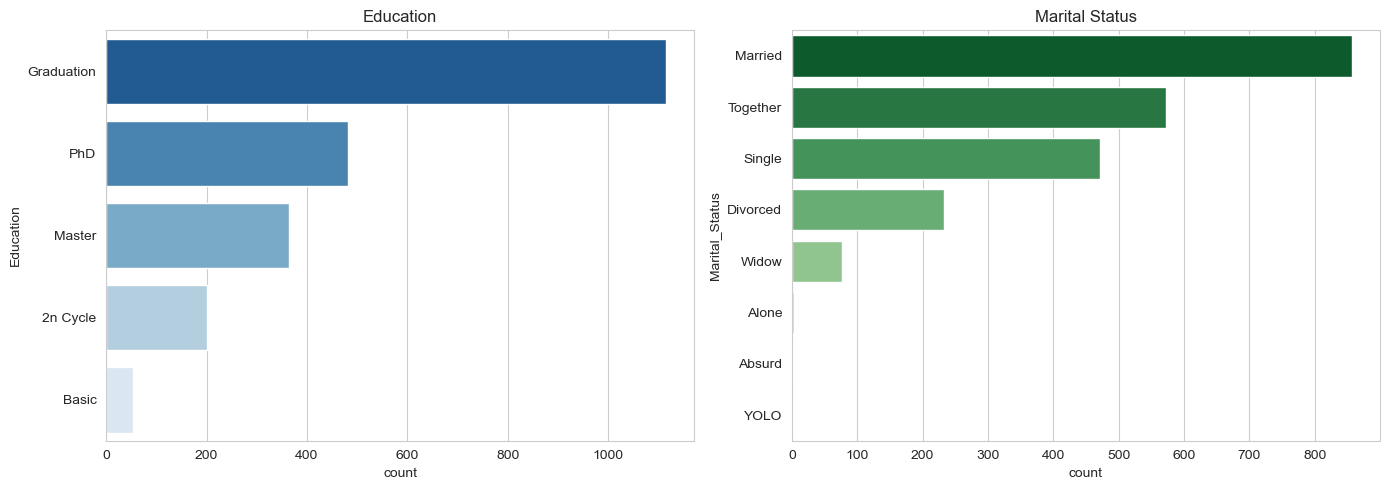

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(y=df["Education"], order=df["Education"].value_counts().index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Education")

sns.countplot(y=df["Marital_Status"], order=df["Marital_Status"].value_counts().index, ax=axes[1], palette="Greens_r")
axes[1].set_title("Marital Status")
plt.tight_layout()
plt.show()

## Key Observations

- Several numeric columns (spending amounts, purchase counts) are right-skewed, which is expected for transactional data.
- `Age` (derived from `Year_Birth`) and `Income` contain a small number of extreme outliers, handled in the next notebook.
- `Education` and `Marital_Status` are unbalanced categorical features with a few rare categories.